In [ ]:
import sys
import os
import pickle

root_dir = os.path.abspath("..")
package_dir = os.path.abspath("../current_setpoints")
optimization_dir = os.path.abspath("../current_setpoints/optimization")
model_dir = os.path.abspath("../current_setpoints/model")

for path in [root_dir, package_dir, optimization_dir, model_dir]:
    if path not in sys.path:
        sys.path.append(path)

from current_setpoints.data import IEEEMachine2, FluxValues
from current_setpoints.model import Transform
from current_setpoints.optimization import ModelAnalytical, MotorOptimizer, calculate_grid, grid_to_data
from current_setpoints.utils.plotting import plot_grid_segments

In [2]:
flux_registry = FluxValues()

machine = IEEEMachine2(flux_values=flux_registry)

nmax = 1800
machine.set_max_pars(curr_max=30.0, volt_max=13.0, omega_max=nmax)
transform = Transform(machine=machine, omega=0.0, add_volt_0=False)

analytical_model = ModelAnalytical(machine=machine)
solver_opts = {"disp": False, "ftol": 1e-8, "maxiter": 500, "eps": 1e-8}
optimizer = MotorOptimizer(model=analytical_model, opts=solver_opts)

grid_opts = {"n_torq": 21, "n_omega": 21, "torq_min": 7.5, "omega_min": 0.0}

In [6]:
print("Starting grid calculation. This may take a few minutes...")

grid_result = calculate_grid(
    optimizer=optimizer, transform=transform, opts=grid_opts, mode="standard"
)

filename = os.path.join("..", "data", "IEETIE_machine2_baseline.pkl")

with open(filename, "wb") as file:
    pickle.dump(grid_result, file)

print(f"Grid successfully calculated and saved to '{filename}'")

Starting grid calculation. This may take a few minutes...
Starting Standard Grid Calculation...
Calculating: Omega step 1/21 (0.0 RPM)
Calculating: Omega step 2/21 (90.0 RPM)
Calculating: Omega step 3/21 (180.0 RPM)
Calculating: Omega step 4/21 (270.0 RPM)
Calculating: Omega step 5/21 (360.0 RPM)
Calculating: Omega step 6/21 (450.0 RPM)
Calculating: Omega step 7/21 (540.0 RPM)
Calculating: Omega step 8/21 (630.0 RPM)
Calculating: Omega step 9/21 (720.0 RPM)
Calculating: Omega step 10/21 (810.0 RPM)
Calculating: Omega step 11/21 (900.0 RPM)
Calculating: Omega step 12/21 (990.0 RPM)
Calculating: Omega step 13/21 (1080.0 RPM)
Calculating: Omega step 14/21 (1170.0 RPM)
Calculating: Omega step 15/21 (1260.0 RPM)
Calculating: Omega step 16/21 (1350.0 RPM)
Calculating: Omega step 17/21 (1440.0 RPM)
Calculating: Omega step 18/21 (1530.0 RPM)
Calculating: Omega step 19/21 (1620.0 RPM)
Calculating: Omega step 20/21 (1710.0 RPM)
Calculating: Omega step 21/21 (1800.0 RPM)
Standard Grid Calculation

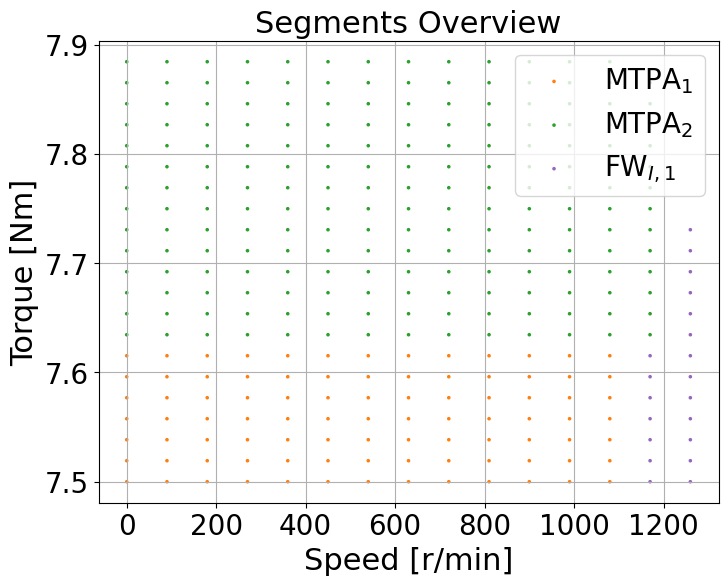

In [7]:
machine_data = grid_to_data(grid_result, k_skip=1)
plot_grid_segments(machine_data)

In [ ]:
import torch
from current_setpoints.optimization import ModelNeural
from current_setpoints.utils.neural import load_neural_model

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_SAVE_PATH = "../weights/NTM_Best_Model.pth"   
SCALER_SAVE_PATH = "../weights/NTM_Best_Scaler.npy" 

INPUT_SIZE = 5
OPTIMAL_HIDDEN_SIZE = 16

print("Loading trained NeuralTorquePredictor...")
neural_net, scaler = load_neural_model(
    weights_path=MODEL_SAVE_PATH,
    scaler_path=SCALER_SAVE_PATH,
    hidden_size=OPTIMAL_HIDDEN_SIZE,
    input_size=INPUT_SIZE,
    machine=machine,
    device=DEVICE
)

neural_model_wrapper = ModelNeural(
    machine=machine, 
    neural_model=neural_net, 
    scaler=scaler, 
    device=DEVICE
)

solver_opts_neural = {"disp": False, "ftol": 1e-5, "maxiter": 2500, "eps": 1e-4}
neural_optimizer = MotorOptimizer(model=neural_model_wrapper, opts=solver_opts_neural)

print("Starting Neural Grid calculation. This may take longer due to network inference...")

neural_grid_result = calculate_grid(
    optimizer=neural_optimizer, 
    transform=transform, 
    opts=grid_opts, 
    mode="standard" 
)

neural_filename = os.path.join("..", "data", "IEETIE_machine2_compensated.plk")

with open(neural_filename, "wb") as file:
    pickle.dump(neural_grid_result, file)

print(f"Neural Grid successfully calculated and saved to '{neural_filename}'")

neural_machine_data = grid_to_data(neural_grid_result, k_skip=1)
plot_grid_segments(neural_machine_data)

Loading trained NeuralTorquePredictor...


RuntimeError: Error(s) in loading state_dict for NeuralTorquePredictor:
	size mismatch for fc1.weight: copying a param with shape torch.Size([16, 5]) from checkpoint, the shape in current model is torch.Size([12, 5]).
	size mismatch for fc1.bias: copying a param with shape torch.Size([16]) from checkpoint, the shape in current model is torch.Size([12]).
	size mismatch for fc2.weight: copying a param with shape torch.Size([1, 16]) from checkpoint, the shape in current model is torch.Size([1, 12]).